We decided to work with CIFAR-10 for the Project.
1. load data
- Load training and test sets
- Verify shapes
- Verify data types
- Verify labels
2. EDA:
  - print dataset shape & pixel range
  - print classes (class imbalance)
  - check for duplicates
  - check for blanks
  - Visualization:
    - random (32 images)
    - random images per class
3. Data Preprocessing
  - Normalizing values
  - One-hot encoding (to_categorical())
  - Split the data
    Training set
    Validation set
    Test set
    Use stratification if appropriate ?
  - Data augmentation
    Examples:
    Horizontal flip
    Small rotations
    Zoom
    Width/height shifts
    (Apply only to the training set.)
 4. Build a CNN from Scratch

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np

In [3]:
x_temp = np.load('/content/drive/MyDrive/cifar10_data/x_train.npy')
y_temp = np.load('/content/drive/MyDrive/cifar10_data/y_train.npy')
x_test = np.load('/content/drive/MyDrive/cifar10_data/x_test.npy')
y_test = np.load('/content/drive/MyDrive/cifar10_data/y_test.npy')

In [4]:
import tensorflow as tf

x_temp = tf.image.resize(x_temp, [32, 32]).numpy()
x_test  = tf.image.resize(x_test,  [32, 32]).numpy()

np.save('/content/drive/MyDrive/cifar10_data/x_train.npy', x_temp)
np.save('/content/drive/MyDrive/cifar10_data/x_test.npy',  x_test)

print("Done! Shapes:")
print("x_train:", x_temp.shape)
print("x_test: ", x_test.shape)

Done! Shapes:
x_train: (50000, 32, 32, 3)
x_test:  (10000, 32, 32, 3)


In [ ]:
print(x_temp.min(), x_temp.max())

0.0 1.0


In [ ]:
print("x_temp:", x_temp.shape)
print("y_temp:", y_temp.shape)
print("x_test :", x_test.shape)
print("y_test :", y_test.shape)

x_temp: (50000, 32, 32, 3)
y_temp: (50000, 10)
x_test : (10000, 32, 32, 3)
y_test : (10000, 10)


In [ ]:
import numpy as np

classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
labels, counts = np.unique(np.argmax(y_temp, axis=1), return_counts=True)

for l, c in zip(labels, counts):
    print(f"{classes[int(l)]}: {c}")

airplane: 5000
automobile: 5000
bird: 5000
cat: 5000
deer: 5000
dog: 5000
frog: 5000
horse: 5000
ship: 5000
truck: 5000


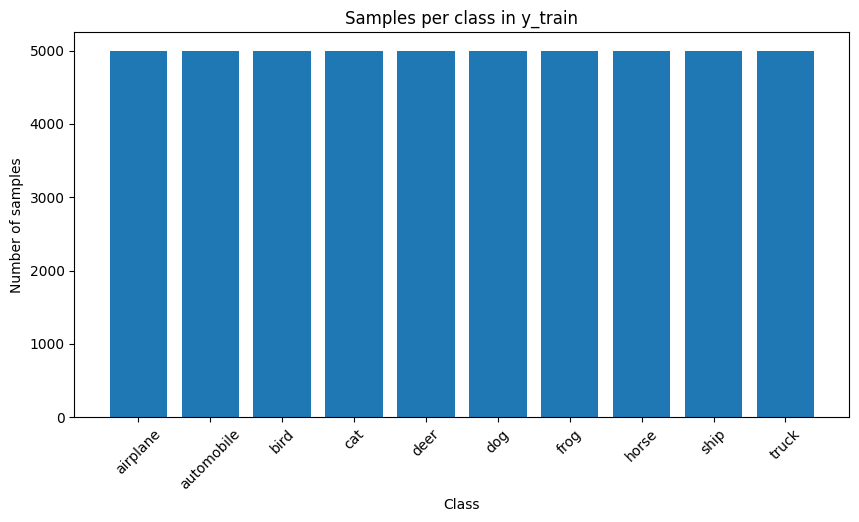

In [8]:
import matplotlib.pyplot as plt

labels, counts = np.unique(np.argmax(y_temp, axis=1), return_counts=True)

plt.figure(figsize=(10,5))
plt.bar([classes[int(l)] for l in labels], counts)
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("Samples per class in y_train")
plt.xticks(rotation=45)
plt.show()

In [9]:
# Basic info & pixel range
print("=== Dataset shapes ===")
print(f"x_temp: {x_temp.shape}")
print(f"y_temp: {y_temp.shape}")
print(f"x_test:  {x_test.shape}")
print(f"y_test:  {y_test.shape}")

print("\n=== Pixel values ===")
print(f"Min: {x_temp.min()}")
print(f"Max: {x_temp.max()}")
print(f"Mean: {x_temp.mean():.4f}")

=== Dataset shapes ===
x_temp: (50000, 32, 32, 3)
y_temp: (50000, 10)
x_test:  (10000, 32, 32, 3)
y_test:  (10000, 10)

=== Pixel values ===
Min: 0.0
Max: 1.0
Mean: 0.4734


In [10]:
# Duplicates?

# x_flat = x_temp.reshape(len(x_temp), -1)
# unique = np.unique(x_flat, axis=0)
# print(f"Total images:  {len(x_temp)}")
# print(f"Unique images: {len(unique)}")
# print(f"Duplicates:    {len(x_temp) - len(unique)}")


In [11]:
# blank images? if all pixels same value -> is blank

# blank = [i for i in range(len(x_temp)) if x_temp[i].std() == 0]
# print(f"Blank/corrupt images: {len(blank)}")

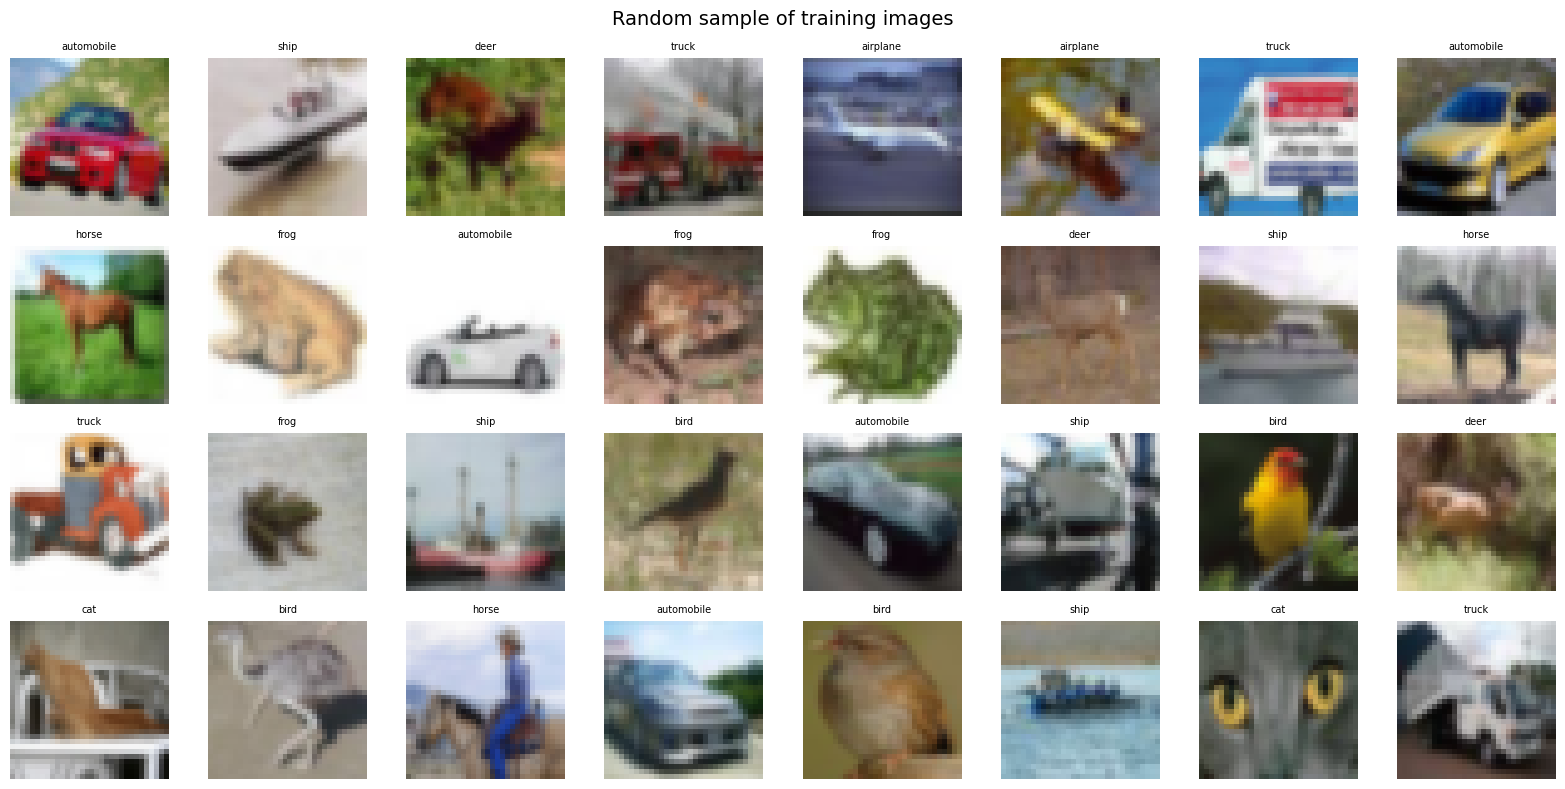

In [12]:
# random plot of images

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

random_indices = np.random.choice(len(x_temp), 32, replace=False)

for i, idx in enumerate(random_indices):
    axes[i].imshow(x_temp[idx])
    axes[i].set_title(classes[np.argmax(y_temp[idx])], fontsize=7)
    axes[i].axis('off')

plt.suptitle('Random sample of training images', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
print(y_temp.shape)
print(y_temp[0])

(50000, 10)
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


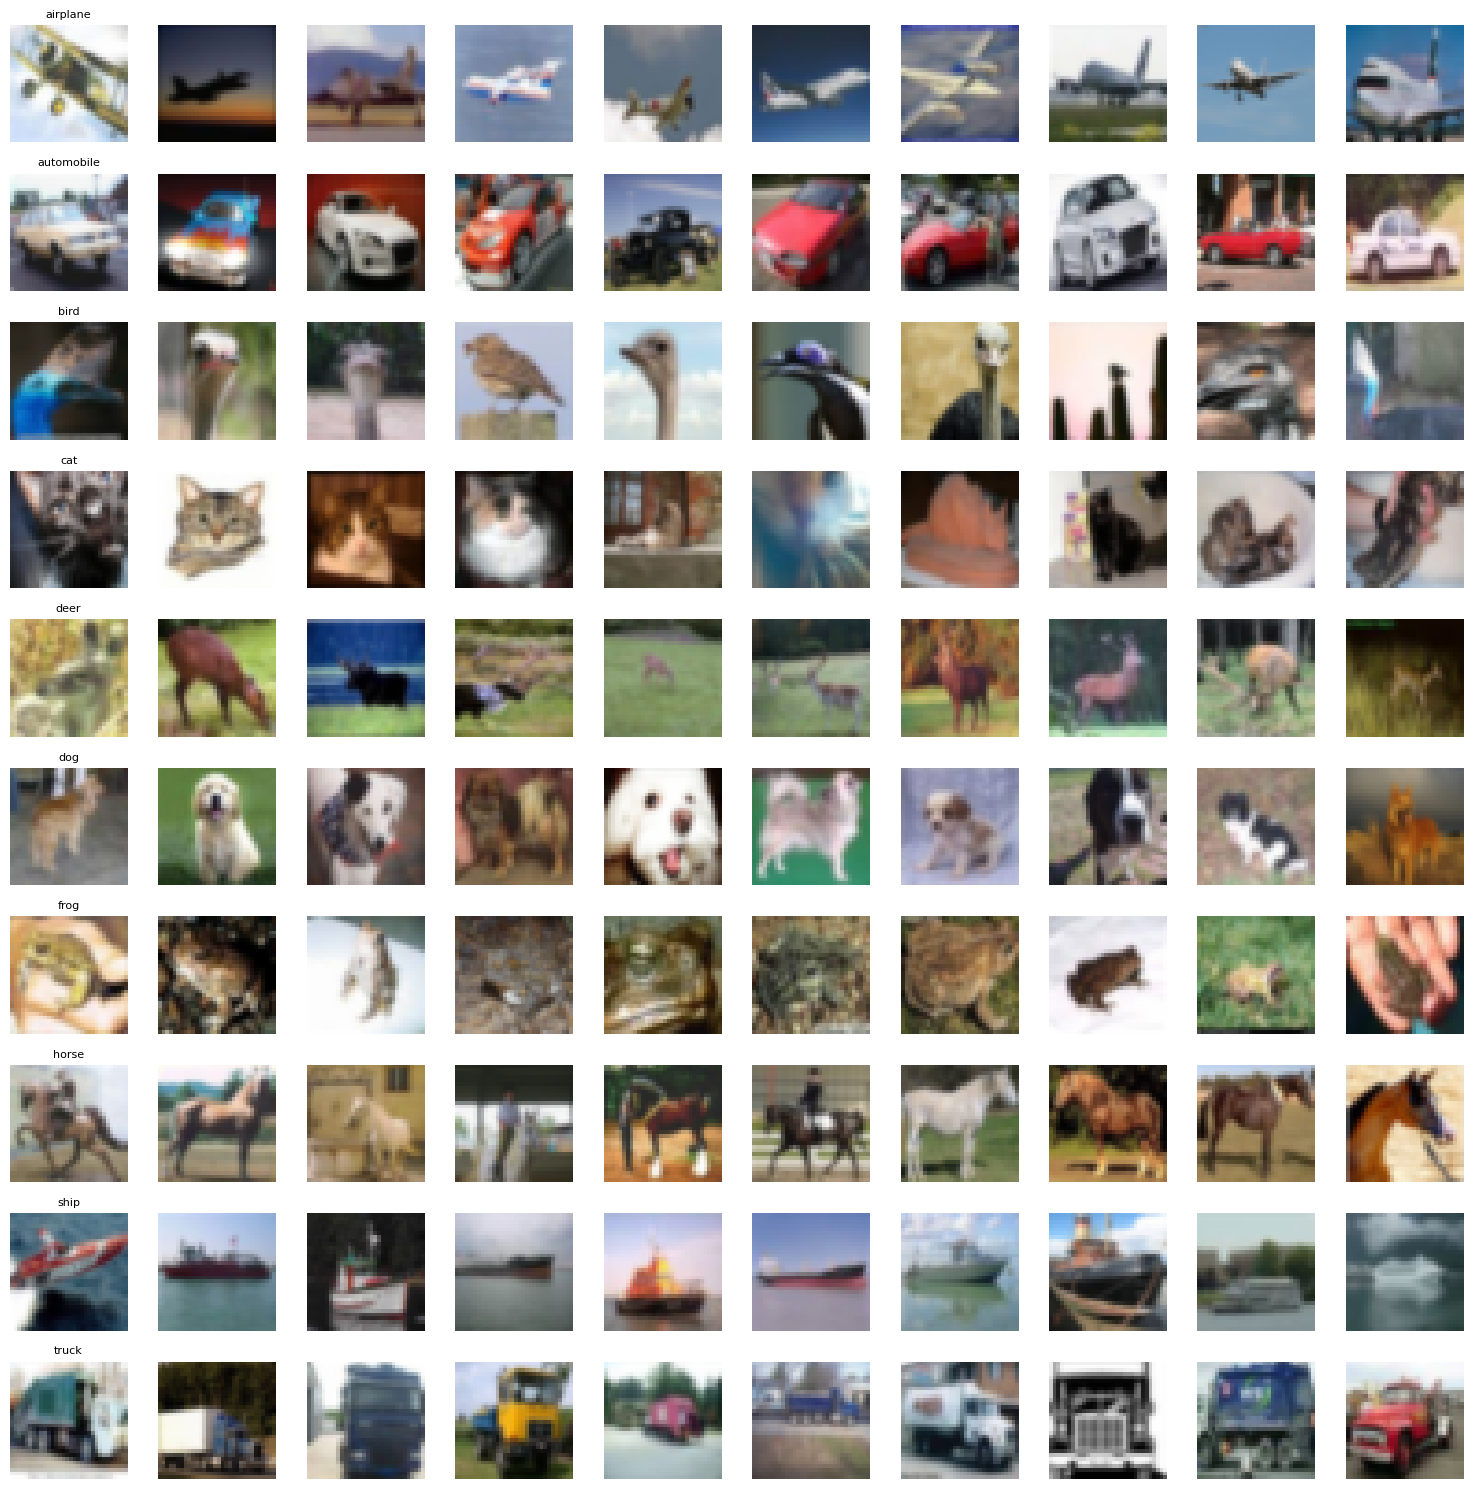

In [14]:
# Visualise samples/class

fig, axes = plt.subplots(10, 10, figsize=(15, 15))

y_temp_labels = np.argmax(y_temp, axis=1)  # recover integer labels

for class_idx in range(10):
    class_indices = np.where(y_temp_labels == class_idx)[0]
    sample_indices = np.random.choice(class_indices, 10, replace=False)
    for col, img_idx in enumerate(sample_indices):
        axes[class_idx, col].imshow(x_temp[img_idx])
        axes[class_idx, col].axis('off')
        if col == 0:
            axes[class_idx, col].set_title(classes[class_idx], fontsize=8)

plt.tight_layout()
plt.show()

In [15]:
from sklearn.model_selection import train_test_split

# x_train, y_train from CIFAR-10's original train set
x_train, x_val, y_train, y_val = train_test_split(
    x_temp, y_temp,
    test_size=0.18,
    stratify=y_temp.argmax(axis=1),    # keep class balance
    random_state=42
)

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_val  :", x_val.shape)
print("y_val  :", y_val.shape)

x_train: (41000, 32, 32, 3)
y_train: (41000, 10)
x_val  : (9000, 32, 32, 3)
y_val  : (9000, 10)


In [16]:
from tensorflow.keras.utils import to_categorical


# x_train = x_train.astype('float32') / 255.0
#x_test  = x_test.astype('float32') / 255.0

# x_val = x_val.astype('float32') / 255.0
# y_val = to_categorical(y_val, num_classes=10)

# y_train = to_categorical(y_train, num_classes=10)
# y_test  = to_categorical(y_test, num_classes=10)

print("x_train shape:", x_train.shape)
# print("y_train shape:", y_train.shape)
print("x_test shape: ", x_test.shape)
# print("y_test shape: ", y_test.shape)
print("x_val shape:  ", x_val.shape)
# print("y_val shape:  ", y_val.shape)

x_train shape: (41000, 32, 32, 3)
x_test shape:  (10000, 32, 32, 3)
x_val shape:   (9000, 32, 32, 3)


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    BatchNormalization
)

model = Sequential([

    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),


     Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),


    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),


    Flatten(),
    Dense(128, activation='relu'),


    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161,098 (629.29 KB)

 Trainable params: 160,650 (627.54 KB)

 Non-trainable params: 448 (1.75 KB)

In [18]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Learning rate:", model.optimizer.learning_rate.numpy())

Learning rate: 1e-04


In [19]:
import time

start = time.time()

history = model.fit(
    x_train, y_train,
    epochs=40,
    batch_size=32,
    validation_data=(x_val, y_val)
)

end = time.time()
print(f"\nTraining time: {(end - start)/60:.1f} minutes")
print(f"Final train accuracy:      {history.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")

Epoch 1/40
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.4359 - loss: 1.6109 - val_accuracy: 0.5239 - val_loss: 1.3699
Epoch 2/40
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5738 - loss: 1.2140 - val_accuracy: 0.5771 - val_loss: 1.2064
Epoch 3/40
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6307 - loss: 1.0557 - val_accuracy: 0.6078 - val_loss: 1.1201
Epoch 4/40
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6750 - loss: 0.9406 - val_accuracy: 0.6126 - val_loss: 1.1156
Epoch 5/40
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7057 - loss: 0.8504 - val_accuracy: 0.6443 - val_loss: 1.0267
Epoch 6/40
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7357 - loss: 0.7736 - val_accuracy: 0.6387 - val_loss: 1.0679
Epoch 7/40
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7551 - loss: 0.7106 - val_accuracy: 0.6436 - val_loss: 1.0633
Epoch 8/40
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7795 - loss: 0.6491 

In [20]:
import numpy as np

y_pred_prob = model.predict(x_val)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

# Convert one-hot encoded labels back to integers
y_true = np.argmax(y_val, axis=1)

282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

<Figure size 1000x800 with 0 Axes>

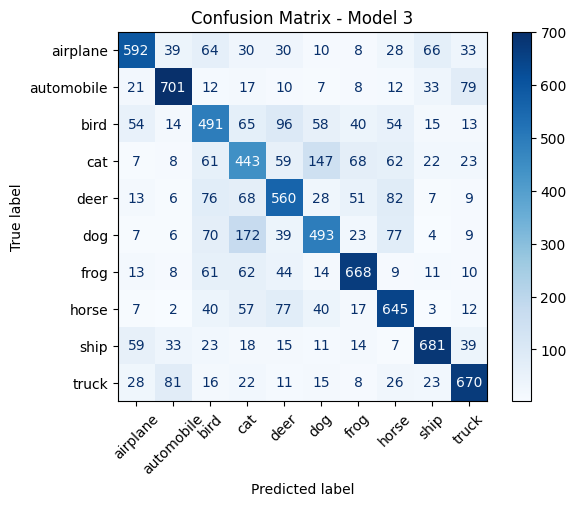

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

classes = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

plt.figure(figsize=(10,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(cmap='Blues', xticks_rotation=45)

plt.title("Confusion Matrix - Model 3")
plt.show()

In [23]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=classes
))

              precision    recall  f1-score   support

    airplane       0.74      0.66      0.70       900
  automobile       0.78      0.78      0.78       900
        bird       0.54      0.55      0.54       900
         cat       0.46      0.49      0.48       900
        deer       0.60      0.62      0.61       900
         dog       0.60      0.55      0.57       900
        frog       0.74      0.74      0.74       900
       horse       0.64      0.72      0.68       900
        ship       0.79      0.76      0.77       900
       truck       0.75      0.74      0.75       900

    accuracy                           0.66      9000
   macro avg       0.66      0.66      0.66      9000
weighted avg       0.66      0.66      0.66      9000



In [24]:
import os

save_path = "/content/drive/MyDrive/CNN_Models"
os.makedirs(save_path, exist_ok=True)

model.save(os.path.join(save_path, "Model_FM_3.keras"))